In [173]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [174]:
df = pd.read_csv('data/customer_segmentation.csv')
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


In [175]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

In [176]:
df.nunique()

ID                     2240
Year_Birth               59
Education                 5
Marital_Status            8
Income                 1974
Kidhome                   3
Teenhome                  3
Dt_Customer             663
Recency                 100
MntWines                776
MntFruits               158
MntMeatProducts         558
MntFishProducts         182
MntSweetProducts        177
MntGoldProds            213
NumDealsPurchases        15
NumWebPurchases          15
NumCatalogPurchases      14
NumStorePurchases        14
NumWebVisitsMonth        16
AcceptedCmp3              2
AcceptedCmp4              2
AcceptedCmp5              2
AcceptedCmp1              2
AcceptedCmp2              2
Complain                  2
Z_CostContact             1
Z_Revenue                 1
Response                  2
dtype: int64

In [177]:
# Deleting Z_CostContact and Z_Revenue as they dont make any variation in the data
df.drop(columns=['Z_CostContact','Z_Revenue'],inplace=True)

In [178]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [179]:
df.duplicated().sum()

np.int64(0)

In [180]:
# to check which column has null values
for i in df.columns:
    var = df[i].isna().sum()
    if var > 0:
        print(f'Column "{i}" has {var} missing values')

Column "Income" has 24 missing values


In [181]:
# Dropping the rows as it wont affect the data much
df.dropna(inplace=True)

In [182]:
df.shape

(2216, 27)

In [183]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2216.0,5588.353339,3249.376275,0.0,2814.75,5458.5,8421.75,11191.0
Year_Birth,2216.0,1968.820397,11.985554,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2216.0,0.441787,0.536896,0.0,0.00,0.0,1.00,2.0
Teenhome,2216.0,0.505415,0.544181,0.0,0.00,0.0,1.00,2.0
Recency,2216.0,49.012635,28.948352,0.0,24.00,49.0,74.00,99.0
MntWines,2216.0,305.091606,337.327920,0.0,24.00,174.5,505.00,1493.0
MntFruits,2216.0,26.356047,39.793917,0.0,2.00,8.0,33.00,199.0
MntMeatProducts,2216.0,166.995939,224.283273,0.0,16.00,68.0,232.25,1725.0
MntFishProducts,2216.0,37.637635,54.752082,0.0,3.00,12.0,50.00,259.0


<Axes: ylabel='Income'>

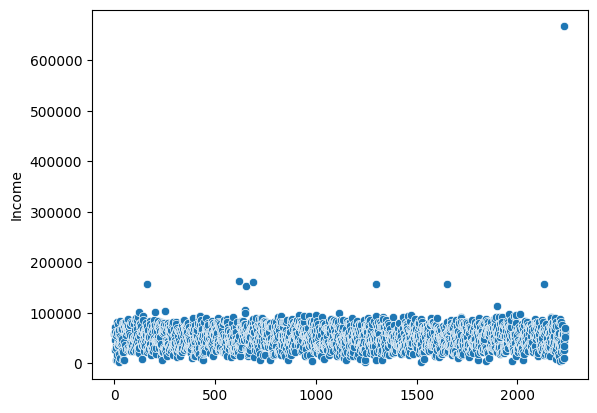

In [184]:
sns.scatterplot(df['Income'])
# The outlier is present in the data and its not affecting the data much but we will going to delete this.

In [185]:
for i in ['Education','Marital_Status','Kidhome','Teenhome']:
    print(df[i].value_counts())

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64
Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64
Kidhome
0    1283
1     887
2      46
Name: count, dtype: int64
Teenhome
0    1147
1    1018
2      51
Name: count, dtype: int64


In [186]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

In [187]:
df['Dt_Customer'].info()

<class 'pandas.Series'>
Index: 2216 entries, 0 to 2239
Series name: Dt_Customer
Non-Null Count  Dtype         
--------------  -----         
2216 non-null   datetime64[us]
dtypes: datetime64[us](1)
memory usage: 34.6 KB


In [188]:
df['Age'] = 2026 - df['Year_Birth']
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,4,7,0,0,0,0,0,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,5,0,0,0,0,0,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,10,4,0,0,0,0,0,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,4,6,0,0,0,0,0,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,6,5,0,0,0,0,0,0,0,45


In [189]:
df['Age'].describe()

count    2216.000000
mean       57.179603
std        11.985554
min        30.000000
25%        49.000000
50%        56.000000
75%        67.000000
max       133.000000
Name: Age, dtype: float64

<Axes: ylabel='Age'>

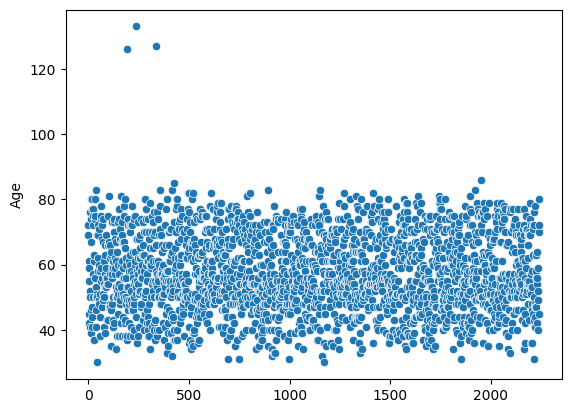

In [190]:
sns.scatterplot(df['Age'])
# The Age column has 3 outliers and Age above 100 isnt possible so we will going to delete those outliers

# Feature Engineering

In [191]:
# Removing the Age outliers
df = df[df['Age'] <= 100]
df.shape

(2213, 28)

<Axes: xlabel='Income', ylabel='Age'>

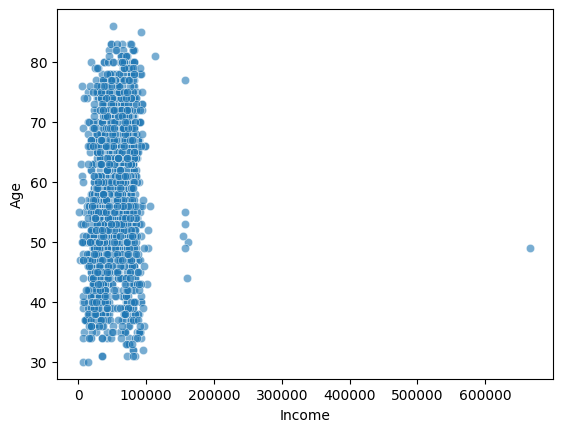

In [192]:
sns.scatterplot(y=df['Age'],x=df['Income'], alpha=0.6)
# Gonna need to remove the outlier in the Income column as well to get a better understanding of the data

In [193]:
df['Age'].describe()

count    2213.000000
mean       57.082693
std        11.700216
min        30.000000
25%        49.000000
50%        56.000000
75%        67.000000
max        86.000000
Name: Age, dtype: float64

In [194]:
df['Income'].describe()

count      2213.000000
mean      52236.581563
std       25178.603047
min        1730.000000
25%       35246.000000
50%       51373.000000
75%       68487.000000
max      666666.000000
Name: Income, dtype: float64

In [195]:
df[df['Income'] >= 600000]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age
2233,9432,1977,Graduation,Together,666666.0,1,0,2013-06-02,23,9,...,3,6,0,0,0,0,0,0,0,49


In [196]:
# Dropped the outlier of Income Column
df = df.drop(df[df['ID'] == 9432].index)

Text(0.5, 1.0, 'Income according to Age ')

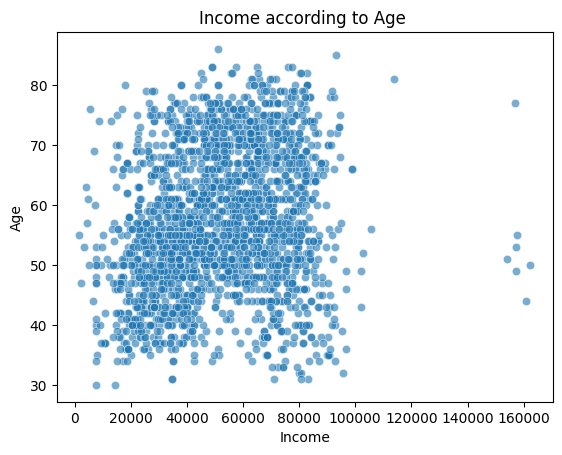

In [197]:
sns.scatterplot(y=df['Age'],x=df['Income'], alpha=0.6)
plt.title("Income according to Age ")
# Zoomed picture of the Age vs Income after the removal of outliers

In [198]:
df['Total_children'] = df['Teenhome'] + df['Kidhome']
df['Total_children']

0       0
1       2
2       0
3       1
4       1
       ..
2235    1
2236    3
2237    0
2238    1
2239    2
Name: Total_children, Length: 2212, dtype: int64

In [199]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response', 'Age', 'Total_children'],
      dtype='str')

In [200]:
temp = ['MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds']
df['Total_spending'] = df[temp].sum(axis=1)
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Total_children,Total_spending
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,0,0,1,69,0,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,0,0,0,72,2,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,0,0,0,61,0,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,0,0,0,42,1,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,0,0,0,45,1,422


In [201]:
df[['MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases','NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']]

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
0,635,88,546,172,88,88,3,8,10,4,7
1,11,1,6,2,1,6,2,1,1,2,5
2,426,49,127,111,21,42,1,8,2,10,4
3,11,4,20,10,3,5,2,2,0,4,6
4,173,43,118,46,27,15,5,5,3,6,5
...,...,...,...,...,...,...,...,...,...,...,...
2235,709,43,182,42,118,247,2,9,3,4,5
2236,406,0,30,0,0,8,7,8,2,5,7
2237,908,48,217,32,12,24,1,2,3,13,6
2238,428,30,214,80,30,61,2,6,5,10,3


In [202]:
# NOTE: " Number of puchase " & " Amount spent " are different

In [203]:
temp = ['NumDealsPurchases', 'NumWebPurchases','NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']
df['Total_num_purchase'] = df[temp].sum(axis=1)
df['Total_num_purchase']

0       32
1       11
2       25
3       14
4       24
        ..
2235    23
2236    29
2237    25
2238    26
2239    18
Name: Total_num_purchase, Length: 2212, dtype: int64

In [204]:
temp = ['AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1','AcceptedCmp2']
df['Total_campaign_accepted'] = df[temp].sum(axis=1)
df['Total_campaign_accepted']

# Customers who accepted more campaigns = highly engaged customers = target them first for future campaigns

0       0
1       0
2       0
3       0
4       0
       ..
2235    0
2236    1
2237    1
2238    0
2239    0
Name: Total_campaign_accepted, Length: 2212, dtype: int64

In [205]:
df['Total_campaign_accepted'].value_counts()

Total_campaign_accepted
0    1754
1     322
2      81
3      44
4      11
Name: count, dtype: int64

# EDA

<Axes: xlabel='Kidhome', ylabel='count'>

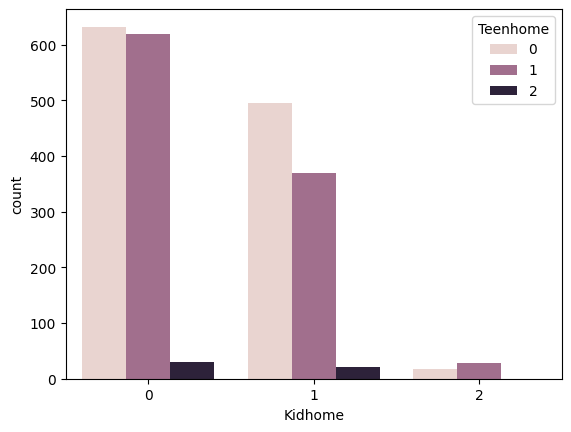

In [206]:
sns.countplot(data=df, x = 'Kidhome',hue='Teenhome')
# The customers who have 2 kids they dont have any teen at home AND the customers who have 2 teens at home they dont have any kid at home.
# And the customer who dont have any kid or teen at home are more than the customers who have at 1 of the Children

In [207]:
df['Kidhome'].value_counts().sum() == len(df)  # should be True

np.True_

In [208]:
df['Total_children'].value_counts()

Total_children
1    1114
0     632
2     416
3      50
Name: count, dtype: int64

In [209]:
df['Total_children'].value_counts().index

Index([1, 0, 2, 3], dtype='int64', name='Total_children')

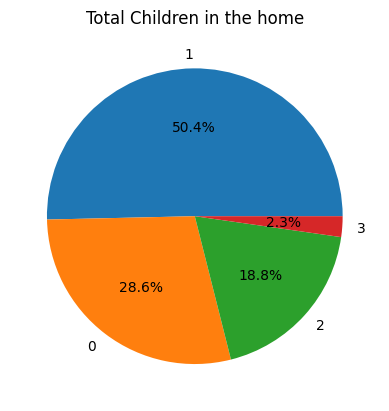

In [210]:
countt = df['Total_children'].value_counts()
plt.pie(countt, labels=countt.index, autopct='%1.1f%%')
plt.title("Total Children in the home")
plt.show()

# ~50% of customers have exactly 1 child, and ~71% have at least 1 child at home.

In [211]:
df['Dt_Customer_month'] = df['Dt_Customer'].dt.month_name()

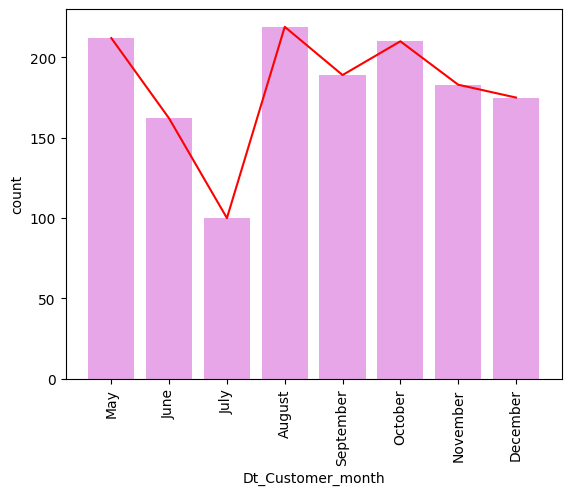

In [212]:
month_order = ['May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
month_counts = df['Dt_Customer_month'].value_counts().reindex(month_order)

sns.countplot(data=df, x='Dt_Customer_month', order=month_order, color='violet',alpha=0.8)
sns.lineplot(x=month_order, y=month_counts.values, color='red')
plt.xticks(rotation=90)
plt.show()

#### Most of the customers were acquired in the month of May and August.

Text(0.5, 1.0, 'Age distribution')

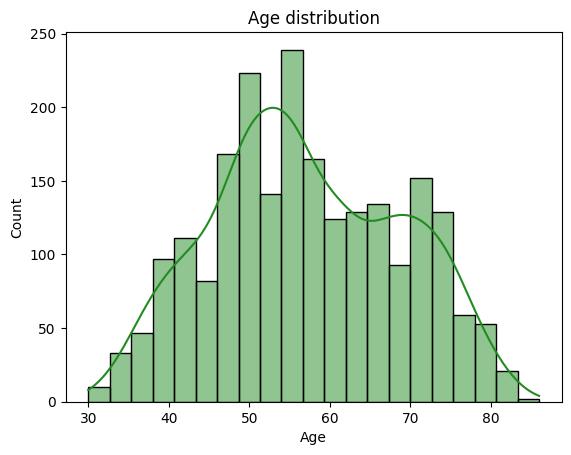

In [213]:
sns.histplot(df['Age'], kde=True, color='forestgreen')
plt.title('Age distribution')
# Most of the Customers age is between 40 to 55

In [214]:
df[df['Age'] > 100]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Total_children,Total_spending,Total_num_purchase,Total_campaign_accepted,Dt_Customer_month


<Axes: xlabel='Income', ylabel='Count'>

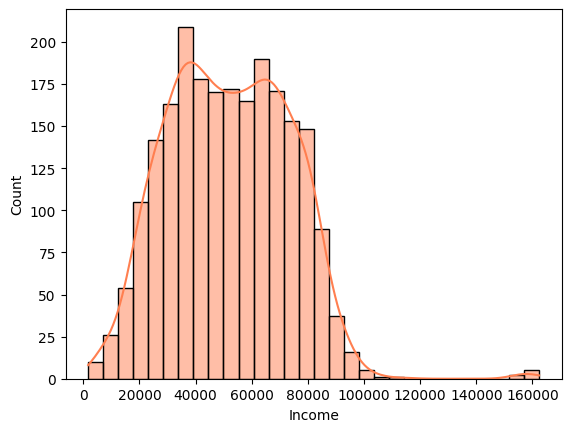

In [215]:
sns.histplot(df['Income'], bins=30, kde=True, color='coral')

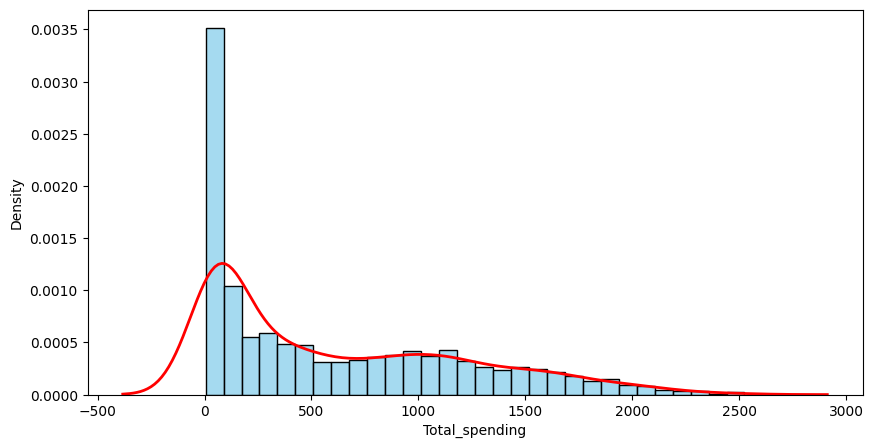

In [216]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['Total_spending'], bins=30, color='skyblue', stat='density', ax=ax)
sns.kdeplot(df['Total_spending'], color='red', linewidth=2, ax=ax)
plt.show()

<Axes: xlabel='Education', ylabel='Income'>

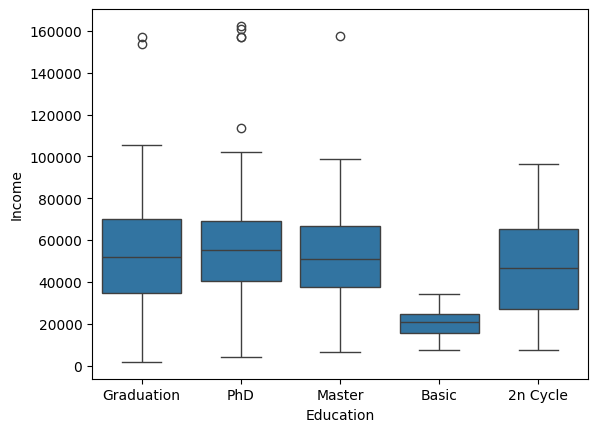

In [217]:
sns.boxplot(data=df, x = 'Education', y='Income')
# Customer whose Education is Basic have the lowest income and PHD persuing customers have the highest income.

<Axes: xlabel='Marital_Status', ylabel='Income'>

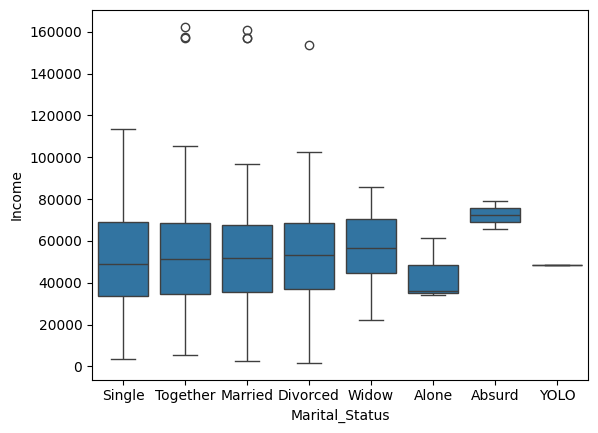

In [218]:
sns.boxplot(data=df, y= "Income", x='Marital_Status')
# Absurd's people has the highest Average income while the HIghest income customers are either married or Living Together

<Axes: xlabel='Education', ylabel='Marital_Status'>

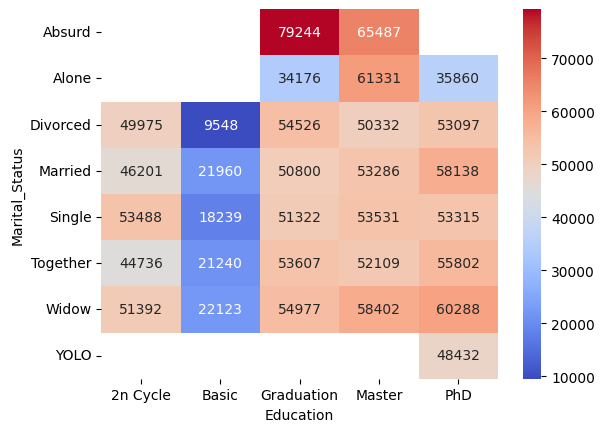

In [219]:
piv = df.pivot_table(columns='Education',index='Marital_Status', values='Income', aggfunc='mean')
sns.heatmap(piv, annot=True, cmap='coolwarm', fmt='.0f')

<Axes: xlabel='Marital_Status', ylabel='Total_spending'>

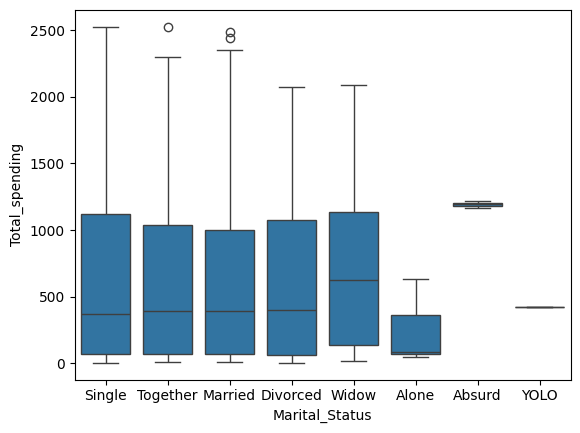

In [220]:
sns.boxplot(data=df, y= "Total_spending", x='Marital_Status')
# Single people have the lowest average spending but sometimes they also spend the most

<Axes: xlabel='Income', ylabel='Total_spending'>

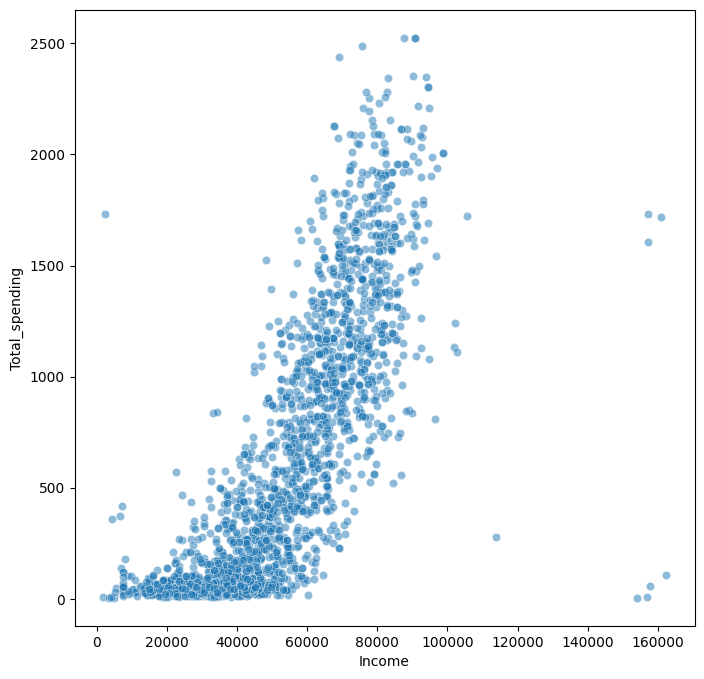

In [221]:
plt.figure(figsize=(8,8))
sns.scatterplot(data = df, x='Income', y='Total_spending', alpha=0.5)
# Total spending makes a linear correlation with the Income, as the income increases the spending also increases

In [222]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response', 'Age', 'Total_children',
       'Total_spending', 'Total_num_purchase', 'Total_campaign_accepted',
       'Dt_Customer_month'],
      dtype='str')

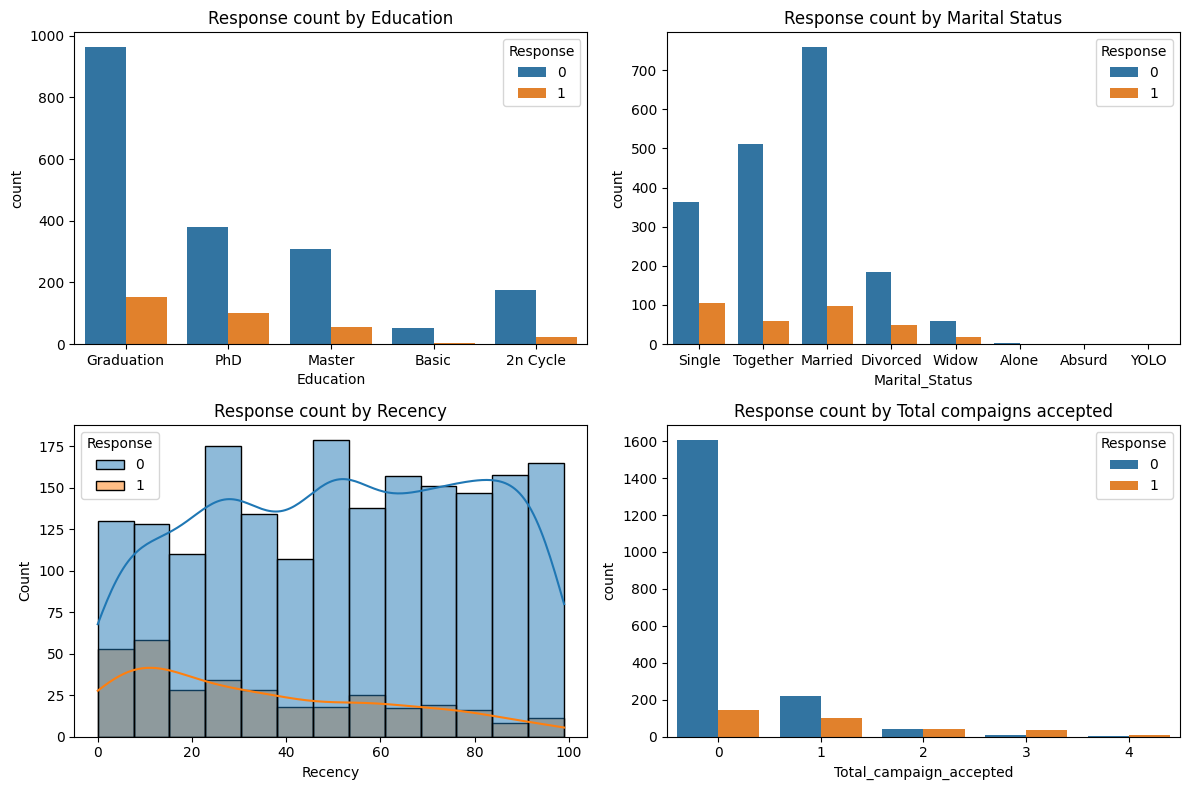

In [223]:
plt.figure(figsize=(12, 8))

plt.subplot(221)
sns.countplot(data=df, x='Education', hue='Response')
plt.title('Response count by Education')

plt.subplot(222)
sns.countplot(data=df, x='Marital_Status', hue='Response')
plt.title('Response count by Marital Status')

plt.subplot(223)
sns.histplot(data=df, x='Recency', hue='Response', kde=True)
plt.title('Response count by Recency')

plt.subplot(224)
sns.countplot(data=df, x='Total_campaign_accepted', hue='Response')
plt.title('Response count by Total compaigns accepted')

plt.tight_layout()
plt.show()

In [224]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response', 'Age', 'Total_children',
       'Total_spending', 'Total_num_purchase', 'Total_campaign_accepted',
       'Dt_Customer_month'],
      dtype='str')

In [225]:
corr = df[['Income','Total_spending','Total_num_purchase','Recency','Total_campaign_accepted']].corr()

<Axes: >

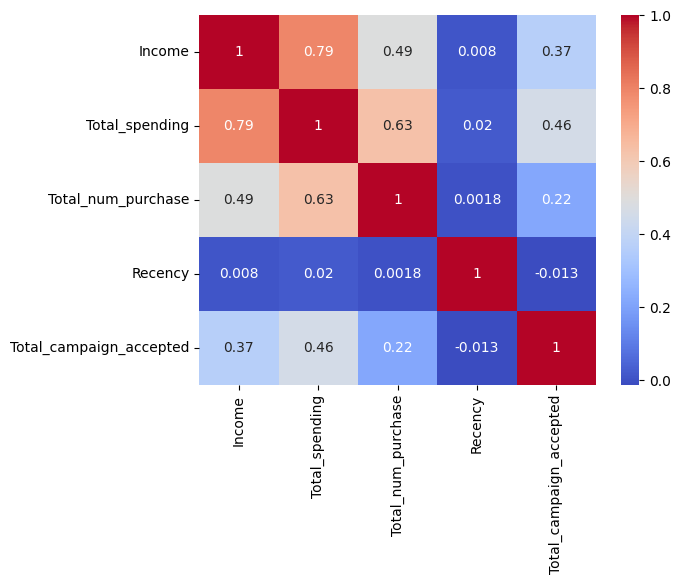

In [226]:
sns.heatmap(corr, annot=True, cmap='coolwarm')

In [227]:
grp1 = df.groupby('Education')['Total_spending'].mean().sort_values(ascending=False)
grp1

Education
PhD           674.283333
Graduation    622.188341
Master        609.767123
2n Cycle      499.489899
Basic          81.796296
Name: Total_spending, dtype: float64

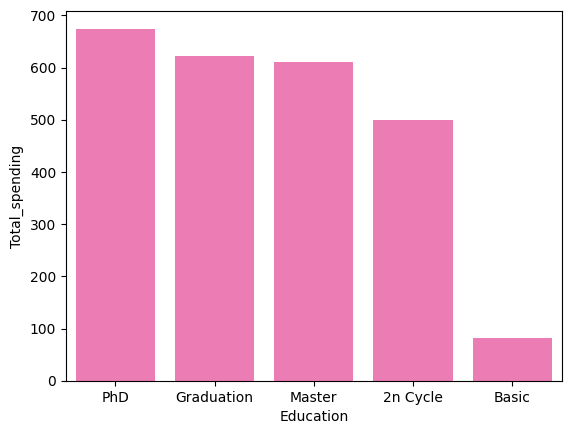

In [228]:
sns.barplot(grp1, color='hotpink')
plt.show()

In [229]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response', 'Age', 'Total_children',
       'Total_spending', 'Total_num_purchase', 'Total_campaign_accepted',
       'Dt_Customer_month'],
      dtype='str')

In [230]:
df[['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']]

,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response
0,0,0,0,0,0,1
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0
...,...,...,...,...,...,...
2235,0,0,0,0,0,0
2236,1,0,0,0,0,0
2237,0,0,0,1,0,0
2238,0,0,0,0,0,0


In [231]:
df['AcceptedAny'] = df[['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']].sum(axis=1)
df['AcceptedAny']

0       1
1       0
2       0
3       0
4       0
       ..
2235    0
2236    1
2237    1
2238    0
2239    1
Name: AcceptedAny, Length: 2212, dtype: int64

In [232]:
df['AcceptedAny'] = df['AcceptedAny'].apply(lambda x: 1 if x>0 else 0)

In [233]:
df['AcceptedAny'].value_counts()

AcceptedAny
0    1608
1     604
Name: count, dtype: int64

In [234]:
grp2 = df.groupby('Marital_Status')['AcceptedAny'].mean().sort_values(ascending=False)

In [235]:
grp2

Marital_Status
Absurd      0.500000
YOLO        0.500000
Widow       0.342105
Alone       0.333333
Single      0.312766
Divorced    0.298701
Married     0.252042
Together    0.250438
Name: AcceptedAny, dtype: float64

<Axes: xlabel='Marital_Status', ylabel='AcceptedAny'>

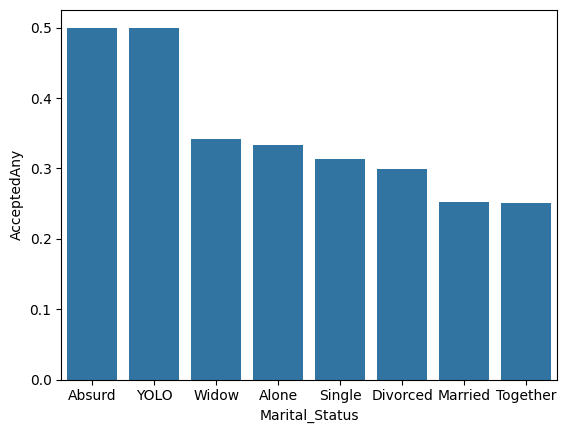

In [236]:
sns.barplot(data=grp2)

In [237]:
bins = [18,30,40,50,60,70,90]
labels = ['18-29', '30-39', '40-49', '50-59', '60-69', '70-89']
df['Age_group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
df['Age_group']

0       60-69
1       70-89
2       60-69
3       40-49
4       40-49
        ...  
2235    50-59
2236    70-89
2237    40-49
2238    70-89
2239    70-89
Name: Age_group, Length: 2212, dtype: category
Categories (6, str): ['18-29' < '30-39' < '40-49' < '50-59' < '60-69' < '70-89']

In [238]:
grp3 = df.groupby('Age_group')['Income'].mean()
grp3

Age_group
30-39    48679.664384
40-49    46367.452539
50-59    50080.818689
60-69    55373.906250
70-89    58494.663462
Name: Income, dtype: float64

In [239]:
df['Age'].describe()

count    2212.000000
mean       57.086347
std        11.701599
min        30.000000
25%        49.000000
50%        56.000000
75%        67.000000
max        86.000000
Name: Age, dtype: float64

Text(0.5, 1.0, 'Average Income by Age Group')

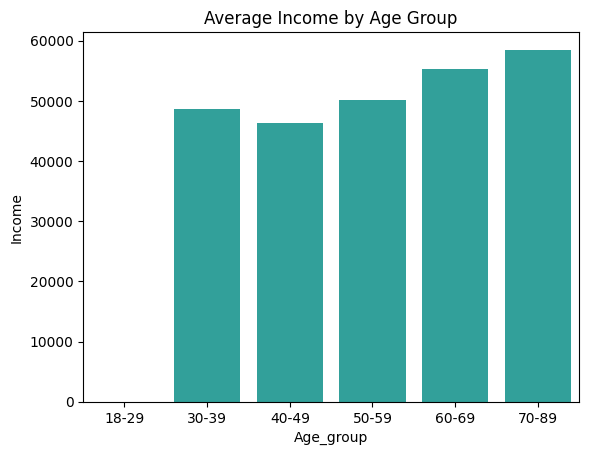

In [240]:
sns.barplot(data=grp3, color='lightseagreen')
plt.title("Average Income by Age Group")

In [241]:
# By default, pd.cut uses (left, right] — meaning:

# 18-29 bin is actually (18, 30] — includes 30!
# So age = 30 falls into the 18-29 bucket, not 30-39

In [242]:
df['Age_group'].value_counts()

Age_group
50-59    717
60-69    480
40-49    453
70-89    416
30-39    146
18-29      0
Name: count, dtype: int64

In [243]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response', 'Age', 'Total_children',
       'Total_spending', 'Total_num_purchase', 'Total_campaign_accepted',
       'Dt_Customer_month', 'AcceptedAny', 'Age_group'],
      dtype='str')

In [244]:
features = ['Age','Income','Total_spending','Total_num_purchase','Recency','Total_campaign_accepted']

X = df[features].copy()

In [245]:
X

,Age,Income,Total_spending,Total_num_purchase,Recency,Total_campaign_accepted
0,69,58138.0,1617,32,58,0
1,72,46344.0,27,11,38,0
2,61,71613.0,776,25,26,0
3,42,26646.0,53,14,26,0
4,45,58293.0,422,24,94,0
...,...,...,...,...,...,...
2235,59,61223.0,1341,23,46,0
2236,80,64014.0,444,29,56,1
2237,45,56981.0,1241,25,91,1
2238,70,69245.0,843,26,8,0


In [246]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 1.01835202,  0.28710487,  1.67624537,  1.61910137,  0.31035323,
        -0.43915996],
       [ 1.27478522, -0.26088203, -0.96329696, -1.26551094, -0.38081349,
        -0.43915996],
       [ 0.33453017,  0.9131964 ,  0.28011009,  0.65756393, -0.79551352,
        -0.43915996],
       ...,
       [-1.03311355,  0.23334696,  1.05205171,  0.65756393,  1.45077832,
         1.0326913 ],
       [ 1.10382975,  0.80317156,  0.39133608,  0.79492642, -1.41756357,
        -0.43915996],
       [ 1.27478522,  0.04229031, -0.72258398, -0.30397351, -0.31169682,
        -0.43915996]], shape=(2212, 6))

In [247]:
from sklearn.cluster import KMeans
lst = []

for i in range(2,10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    lst.append(kmeans.inertia_)

In [248]:
lst

[8941.144588986055,
 7510.436008117488,
 6770.239223378904,
 6258.279065503492,
 5507.474189447327,
 5040.711521929162,
 4835.528590507385,
 4573.0763902337685]

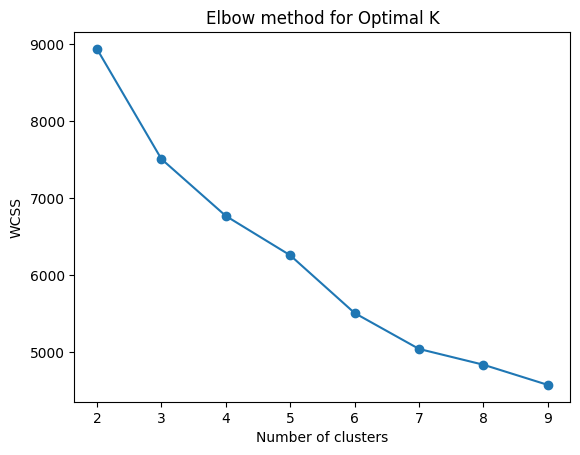

In [249]:
plt.plot(range(2,10),lst,marker='o')
plt.title('Elbow method for Optimal K')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [274]:
# Choosing K=6 as it bends the most according to the Elbow bend method 

In [285]:
kmeans = KMeans(n_clusters=6, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)
df['Cluster'].value_counts()

Cluster
0    544
1    517
5    352
3    339
2    328
4    132
Name: count, dtype: int64

In [286]:
cluster_summary = df.groupby('Cluster')[features].mean()
cluster_summary

,Age,Income,Total_spending,Total_num_purchase,Recency,Total_campaign_accepted
Cluster,,,,,,
0,53.301471,34866.391544,119.058824,14.834559,23.615809,0.101103
1,54.147002,34426.972921,110.429400,14.736944,74.295938,0.067698
2,70.713415,62802.286585,823.881098,23.594512,68.893293,0.250000
3,48.964602,70341.858407,1169.734513,25.572271,62.890855,0.203540
4,55.810606,79894.628788,1553.348485,24.856061,48.560606,2.500000
5,62.855114,65840.045455,993.187500,26.514205,19.448864,0.252841


In [287]:
cluster_names = {
    0: 'Low Income Low Spenders',
    1: 'Low Income Least Spenders',
    2: 'High Age Mid Spenders',
    3: 'Mid Age High Spenders',
    4: 'High Income Premium Buyers',
    5: 'High Age High Spenders'
}

df['Cluster'] = df['Cluster'].map(cluster_names)
cluster_summary.index = cluster_summary.index.map(cluster_names)

In [288]:
cluster_summary

,Age,Income,Total_spending,Total_num_purchase,Recency,Total_campaign_accepted
Cluster,,,,,,
Low Income Low Spenders,53.301471,34866.391544,119.058824,14.834559,23.615809,0.101103
Low Income Least Spenders,54.147002,34426.972921,110.429400,14.736944,74.295938,0.067698
High Age Mid Spenders,70.713415,62802.286585,823.881098,23.594512,68.893293,0.250000
Mid Age High Spenders,48.964602,70341.858407,1169.734513,25.572271,62.890855,0.203540
High Income Premium Buyers,55.810606,79894.628788,1553.348485,24.856061,48.560606,2.500000
High Age High Spenders,62.855114,65840.045455,993.187500,26.514205,19.448864,0.252841


In [289]:
df['Cluster'].value_counts()

Cluster
Low Income Low Spenders       544
Low Income Least Spenders     517
High Age High Spenders        352
Mid Age High Spenders         339
High Age Mid Spenders         328
High Income Premium Buyers    132
Name: count, dtype: int64

In [300]:
df['Recency'].describe()

count    2212.000000
mean       49.019439
std        28.943121
min         0.000000
25%        24.000000
50%        49.000000
75%        74.000000
max        99.000000
Name: Recency, dtype: float64

In [290]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
df['PCA1'],df['PCA2'] = pca_data[:,0], pca_data[:,1]

In [291]:
pca_data 

array([[ 1.8861761 ,  1.09657345],
       [-1.24970614,  0.79987505],
       [ 0.85148797, -0.01159946],
       ...,
       [ 1.26354884, -0.26912658],
       [ 1.03557836,  0.17073071],
       [-0.49675443,  0.9091149 ]], shape=(2212, 2))

In [292]:
df['PCA1']

0       1.886176
1      -1.249706
2       0.851488
3      -1.936160
4      -0.081404
          ...   
2235    0.983531
2236    1.391643
2237    1.263549
2238    1.035578
2239   -0.496754
Name: PCA1, Length: 2212, dtype: float64

In [293]:
df['PCA2']

0       1.096573
1       0.799875
2      -0.011599
3      -1.265753
4       0.409502
          ...   
2235    0.178805
2236    1.287176
2237   -0.269127
2238    0.170731
2239    0.909115
Name: PCA2, Length: 2212, dtype: float64

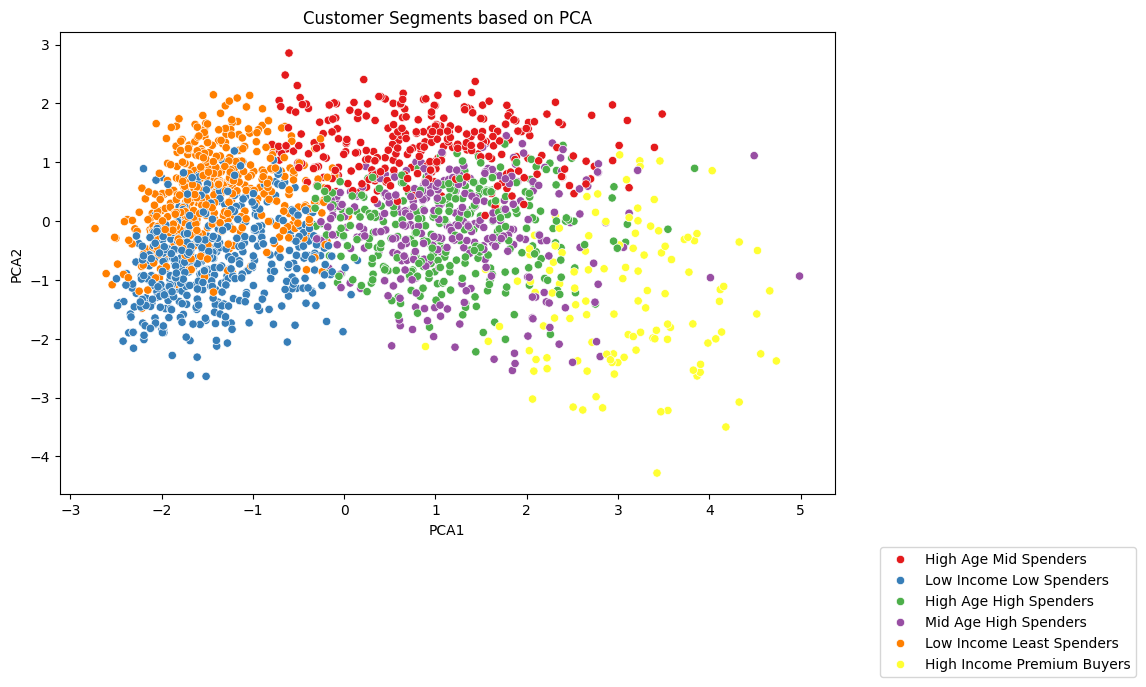

In [294]:
plt.figure(figsize=(10,6))

sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='Set1')
plt.title("Customer Segments based on PCA")
plt.legend(bbox_to_anchor=(1.05, -0.1), loc='upper left')
plt.show()

In [296]:
import joblib
import os

os.makedirs('artifacts', exist_ok=True)
joblib.dump(kmeans, 'artifacts/kmeans_cluster_model.pkl')
joblib.dump(scaler, 'artifacts/scaler.pkl')

['artifacts/scaler.pkl']